In this notebook, the following steps are completed on the labelled dataset:
* Data Cleaning and preprocessing
* Vectorisation of tweets --> word2vec and tf-idf
* Wider Depressive Symptom Identification



Data Cleaning 
* checking for duplicates
* tweet column cleaning 

In [1]:
#initialisation cell - imports and loading up labelled depression dataset
import pandas as pd
import contractions
import re
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import resample
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gensim
from gensim.models import Word2Vec
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
#import pyLDAvis.sklearn
import pyLDAvis.lda_model
from langdetect import detect

tweets = pd.read_csv('Mental-Health-Twitter.csv')
print(tweets.head())

   Unnamed: 0             post_id                    post_created  \
0           0  637894677824413696  Sun Aug 30 07:48:37 +0000 2015   
1           1  637890384576778240  Sun Aug 30 07:31:33 +0000 2015   
2           2  637749345908051968  Sat Aug 29 22:11:07 +0000 2015   
3           3  637696421077123073  Sat Aug 29 18:40:49 +0000 2015   
4           4  637696327485366272  Sat Aug 29 18:40:26 +0000 2015   

                                           post_text     user_id  followers  \
0  It's just over 2 years since I was diagnosed w...  1013187241         84   
1  It's Sunday, I need a break, so I'm planning t...  1013187241         84   
2  Awake but tired. I need to sleep but my brain ...  1013187241         84   
3  RT @SewHQ: #Retro bears make perfect gifts and...  1013187241         84   
4  It’s hard to say whether packing lists are mak...  1013187241         84   

   friends  favourites  statuses  retweets  label  
0      211         251       837         0      1  
1     

In [2]:
pd.set_option('display.max_colwidth', None)
print(tweets['post_text'].head)

<bound method NDFrame.head of 0        It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.
1                                                     It's Sunday, I need a break, so I'm planning to spend as little time as possible on the #A14...
2                                                                                    Awake but tired. I need to sleep but my brain has other ideas...
3        RT @SewHQ: #Retro bears make perfect gifts and are great for beginners too! Get stitching with October's Sew on sale NOW! #yay http://t.co/…
4               It’s hard to say whether packing lists are making life easier or just reinforcing how much still needs doing... #movinghouse #anxiety
                                                                             ...                                                                     
19995                                                                 

In [3]:
print(tweets.info())
print(tweets.describe)

#print(tweets.isnull().sum())
#no null/missing values present in dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    20000 non-null  int64 
 1   post_id       20000 non-null  int64 
 2   post_created  20000 non-null  object
 3   post_text     20000 non-null  object
 4   user_id       20000 non-null  int64 
 5   followers     20000 non-null  int64 
 6   friends       20000 non-null  int64 
 7   favourites    20000 non-null  int64 
 8   statuses      20000 non-null  int64 
 9   retweets      20000 non-null  int64 
 10  label         20000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 1.7+ MB
None
<bound method NDFrame.describe of        Unnamed: 0             post_id                    post_created  \
0               0  637894677824413696  Sun Aug 30 07:48:37 +0000 2015   
1               1  637890384576778240  Sun Aug 30 07:31:33 +0000 2015   
2               2  637749345908051968

In [4]:
#checking for duplicate values 
duplicates = tweets[tweets.duplicated(keep='first')]
print(duplicates)
#data.dropna(inplace=True)
##no duplicates 

Empty DataFrame
Columns: [Unnamed: 0, post_id, post_created, post_text, user_id, followers, friends, favourites, statuses, retweets, label]
Index: []


In [5]:
#convert the post_created column to datetime object
tweets['post_created'] = pd.to_datetime(tweets['post_created'])
#tweets['post_created'] = pd.to_datetime(tweets['post_created'])

C:\Users\mayur\AppData\Local\Temp\ipykernel_30936\295514384.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tweets['post_created'] = pd.to_datetime(tweets['post_created'])


In [6]:
###Tweet column cleaning ###
#for the post_text column specifically as it is longer text more cleaning + preprocessing required

##removing numbers 
def remove_numbers(tweet):
    return ''.join([char for char in tweet if not char.isdigit()])
tweets['post_text'] = tweets['post_text'].apply(remove_numbers)

### fixing contractions  
def fix_contractions(tweet):
    return contractions.fix(tweet)
tweets['post_text'] = tweets['post_text'].apply(fix_contractions)

#### Putting hashtags into a separate column to analyse 
def extract_hashtags(text):
    return list(set(re.findall(r'#(\w+)', text)))

tweets['hashtags'] = tweets['post_text'].apply(extract_hashtags)

### removing punctuation and special characters 
tweets['post_text'] = tweets['post_text'].str.replace('\W',' ',regex=True)


### removing non english text
def remove_non_english_chars(text):
    return re.sub(r'[^\x00-\x7F]+', '', text)
tweets['post_text'] = tweets['post_text'].apply(remove_non_english_chars)

def remove_words_with_number(text):
    return re.sub(r'\b\w*\d\w*\b', '',text)
tweets['post_text'] = tweets['post_text'].apply(remove_words_with_number)
### remove non-alphanumeric characters and extra spaces
def remove_non_alphanumeric(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)
tweets['post_text'] = tweets['post_text'].apply(remove_non_alphanumeric)

def remove_links(text):
    return re.sub(r'(@[A-Za-z0–9_]+)|[^\w\s]|#|http\S+', '',text)
tweets['post_text'] = tweets['post_text'].apply(remove_links)
### removing URLs from tweets
#tweets['post_text'] = tweets['post_text'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
tweets['post_text'] = tweets['post_text'].apply(lambda text: re.sub(r'https?:\/\/\S*', '', text, flags=re.MULTILINE))

### convert text to lower case
tweets['post_text'] = tweets['post_text'].str.lower()

### removing emojis 
def remove_emojis(text):
    #text repesention of emojis 
    emojis_text_rep = emoji.demojize(text)
    clean_text = re.sub(r':[a-zA-Z_]+:', '', emojis_text_rep)
    return clean_text

tweets['post_text'] = tweets['post_text'].apply(remove_emojis)

def remove_non_english_words(text):
    try:
        return detect(text)=='en'
    except:
        return False 
tweets['post_text']= tweets['post_text'].apply(lambda x: '' if not remove_non_english_words(x) else x)
    

print(tweets['post_text'].head)

<>:21: DeprecationWarning: invalid escape sequence '\W'
<>:21: DeprecationWarning: invalid escape sequence '\W'
C:\Users\mayur\AppData\Local\Temp\ipykernel_30936\516560381.py:21: DeprecationWarning: invalid escape sequence '\W'
  tweets['post_text'] = tweets['post_text'].str.replace('\W',' ',regex=True)


<bound method NDFrame.head of 0        it is just over  years since i was diagnosed with  anxiety and  depression  today i am taking a moment to reflect on how far i have come since 
1                                                        it is sunday  i need a break  so i am planning to spend as little time as possible on the  a   
2                                                                                       awake but tired  i need to sleep but my brain has other ideas   
3           rt  sewhq   retro bears make perfect gifts and are great for beginners too  get stitching with october s sew on sale now   yay http   t co  
4                 it is hard to say whether packing lists are making life easier or just reinforcing how much still needs doing     movinghouse  anxiety
                                                                              ...                                                                       
19995                                               

Tokenisation

In [7]:
print(tweets['post_text'].head)

<bound method NDFrame.head of 0        it is just over  years since i was diagnosed with  anxiety and  depression  today i am taking a moment to reflect on how far i have come since 
1                                                        it is sunday  i need a break  so i am planning to spend as little time as possible on the  a   
2                                                                                       awake but tired  i need to sleep but my brain has other ideas   
3           rt  sewhq   retro bears make perfect gifts and are great for beginners too  get stitching with october s sew on sale now   yay http   t co  
4                 it is hard to say whether packing lists are making life easier or just reinforcing how much still needs doing     movinghouse  anxiety
                                                                              ...                                                                       
19995                                               

In [8]:
#Tokenisation - split the text into individual words/tokens
#tweets['post_text'] = tweets['post_text'].apply(lambda x: x.split(' '))
#print(tweets['post_text'].head)

tweets['post_text'] = tweets['post_text'].apply(lambda text: word_tokenize(text))

In [9]:
print(tweets['post_text'].head)

<bound method NDFrame.head of 0        [it, is, just, over, years, since, i, was, diagnosed, with, anxiety, and, depression, today, i, am, taking, a, moment, to, reflect, on, how, far, i, have, come, since]
1                                                                [it, is, sunday, i, need, a, break, so, i, am, planning, to, spend, as, little, time, as, possible, on, the, a]
2                                                                                                     [awake, but, tired, i, need, to, sleep, but, my, brain, has, other, ideas]
3                  [rt, sewhq, retro, bears, make, perfect, gifts, and, are, great, for, beginners, too, get, stitching, with, october, s, sew, on, sale, now, yay, http, t, co]
4                       [it, is, hard, to, say, whether, packing, lists, are, making, life, easier, or, just, reinforcing, how, much, still, needs, doing, movinghouse, anxiety]
                                                                                     

In [10]:
#remove stop words from tweet column
#nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tweets['post_text'] = tweets['post_text'].apply(lambda x: [word for word in x if word not in stop_words])
print(tweets['post_text'])

0                            [years, since, diagnosed, anxiety, depression, today, taking, moment, reflect, far, come, since]
1                                                              [sunday, need, break, planning, spend, little, time, possible]
2                                                                                   [awake, tired, need, sleep, brain, ideas]
3        [rt, sewhq, retro, bears, make, perfect, gifts, great, beginners, get, stitching, october, sew, sale, yay, http, co]
4           [hard, say, whether, packing, lists, making, life, easier, reinforcing, much, still, needs, movinghouse, anxiety]
                                                                 ...                                                         
19995                                                                                   [day, without, sunshine, like, night]
19996                                                         [boren, laws, charge, ponder, trouble, delegate, doubt, 

Eating Disorder and Substance abuse detection - key word detection 

In [11]:
##Eating disorder and Substance abuse detection --> using key words 
##dont have these columns initially when training the classifier, have it after in the training dataset as features and run it through classifier and compare scores , if it inmproves the accuracy of classifer -> that can be contribution
##if additional features change the result of classifer then i can use existing pretrained word2vec model , measure semantic closseness of words in the post
### eating disorder and substance abuse keyword lists

ED_keyword = ['binge eating','binge','starve','starving','body dissatisfaction','body dysmorphia', 'dieting','bulimia','purging','compulsive eating', 'food obsession', 'food obsessed','starve myself','skinny''eating disorder','anorexia','anorexic','purge','purging']
SA_keyword = ['antidepressant','antidepressants','medication','alcohol abuse', 'alcohol','substance abuse','substance','substances', 'drug','drugs','druggie','drug addiction','substance misuse', 'cocaine','coke','weed','opioids','comedown','psychosis','withdrawal', 'cannabis', 'crack','mdma','ecstacy','marijuana','addiction']

## go through post_text column and check for presence of eating disroder key words, if present mark as present in new 'Eating disroder risk 'and substance abuse  column
def ED_SA_detection(text, keywords):
    for keyword in keywords:
        if keyword in text:
            return True
    return False

tweets['eating_disorder risk'] = tweets['post_text'].apply(lambda x: ED_SA_detection(x, ED_keyword))
tweets['substance_abuse risk'] = tweets['post_text'].apply(lambda x: ED_SA_detection(x, SA_keyword))

#print tweets flagged as being an eating disorder risks 
eating_disorder_posts = tweets.loc[tweets['eating_disorder risk']]
print('ED posts')
print(eating_disorder_posts['post_text'])
print()
#prints tweets flaggesd as being an substance abuse  risk 
print('SA posts')
substance_abuse_posts = tweets.loc[tweets['substance_abuse risk']]
print(substance_abuse_posts['post_text'])


ED posts
15                                                                                 [much, stuff, way, way, much, massive, purge, way]
17                                                                                                    [packing, purging, feels, good]
147          [rt, rspcaofficial, marley, amp, zena, dogrescuers, looking, fab, rescue, owner, let, almost, starve, owning, dog, priv]
273                                                                                 [anorexic, woman, weighed, pounds, co, lfsfqgnfl]
652                                                                                     [anorexia, linked, abuse, http, co, dejeqbnd]
692                                                                                       [new, theory, anorexia, http, co, wvyvqeyv]
881                                                                      [treatment, options, someone, anorexia, http, co, ngbqepztp]
1518                                [living, binge, e

Lemmatisation

In [12]:
##lemmatisation
#chose lemmatisation over stemming as it is more accurate 
#nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
#function to apply lemmatisation to each tweet in post_text column
def lemmatisation(tweet):
    #w_tokeniser = nltk.tokenize.WhitespaceTokenizer()
    tweet = [word for word in tweet if word.strip()]

    lemmatiser = WordNetLemmatizer()
    lemmatised_tweet = [lemmatiser.lemmatize(word) for word in tweet]
    #print(lemmatised_tweet)
    return lemmatised_tweet

def lemmatize_tweets(tweet):
    ##initialise wodnetlemmatiser 
    lemmatizer = WordNetLemmatizer()
    lemmatized_sentence = []
    for word, tag in pos_tag(tweet):
        if tag.startswith('NN'):
            #if n then noun
            pos = 'n'  
        elif tag.startswith('VB'):
            #if vb then verb
            pos = 'v'  # Verb
        else:
            ##if not above then adjective
            pos = 'a'  # Adjective
        lemmatized_sentence.append(lemmatizer.lemmatize(word, pos))
    return lemmatized_sentence

tweets['post_text'] = tweets['post_text'].apply(lemmatize_tweets)
print(tweets['post_text'].head)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mayur\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


<bound method NDFrame.head of 0                          [year, since, diagnose, anxiety, depression, today, take, moment, reflect, far, come, since]
1                                                            [sunday, need, break, plan, spend, little, time, possible]
2                                                                               [awake, tire, need, sleep, brain, idea]
3        [rt, sewhq, retro, bear, make, perfect, gift, great, beginner, get, stitch, october, sew, sale, yay, http, co]
4                [hard, say, whether, pack, list, make, life, easy, reinforce, much, still, need, movinghouse, anxiety]
                                                              ...                                                      
19995                                                                             [day, without, sunshine, like, night]
19996                                                    [boren, law, charge, ponder, trouble, delegate, doubt, mumble]
19997    [

EDA - Exploratory Data analysis 


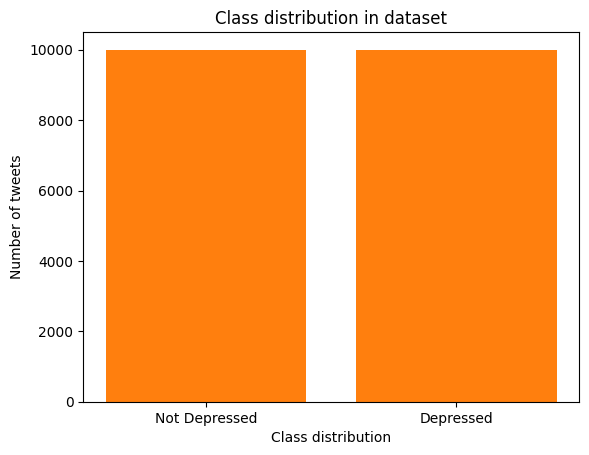

In [13]:
##Checking if the dataset is balanced --> checking balance based on depression labels
# Assuming you have a DataFrame named 'tweets' with a 'label' column (0 for not depressed, 1 for depressed)
labels, counters = np.unique(tweets['label'], return_counts=True)
plt.bar(labels, counters)
x_labels = ['Not Depressed', 'Depressed']
plt.bar(x_labels, counters)
plt.xlabel('Class distribution')
plt.ylabel('Number of tweets')
plt.title('Class distribution in dataset')
plt.show()

In [14]:
#print(tweets.describe)
# group data by 'user_id'
grouped_data = tweets.groupby('user_id')
num_of_unique_users = len(grouped_data)
print('number of unique users: ' ,num_of_unique_users)
user_tweet_counts = tweets['user_id'].value_counts()
print('how many tweets from each user ' ,user_tweet_counts)

number of unique users:  72
how many tweets from each user  user_id
490044008     2117
1458225506    1593
3249600438    1504
145626605     1276
1616997456     888
              ... 
805234081        2
351777130        1
2565061484       1
2848936114       1
3279878459       1
Name: count, Length: 72, dtype: int64


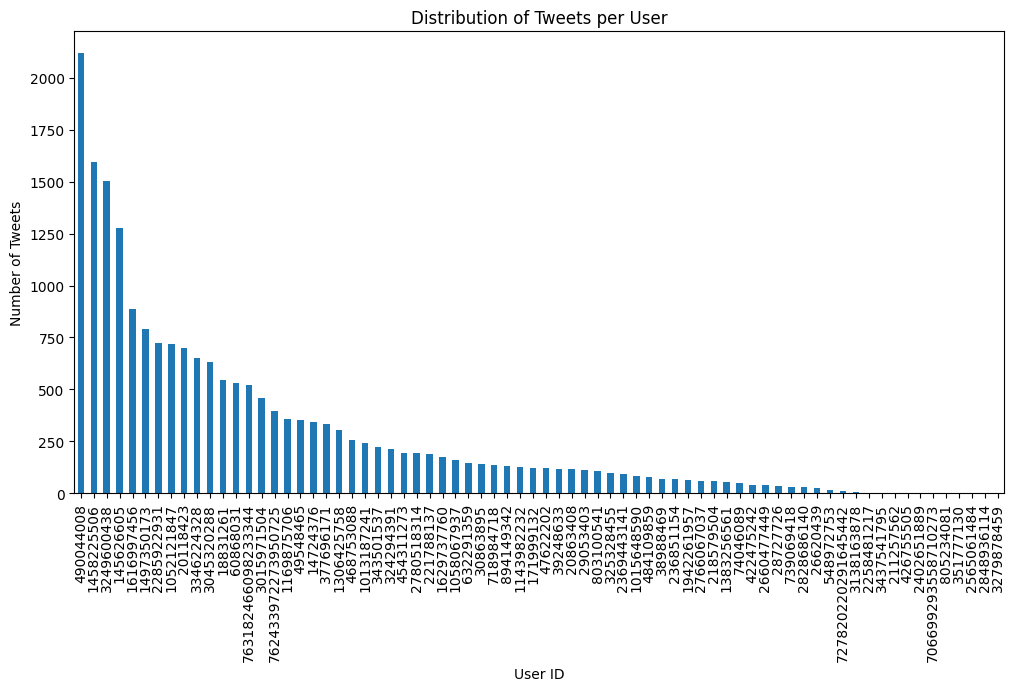

In [15]:
#visualising how many tweets there are from each user 

# Assuming 'user_id' is the column that represents unique users and 'df' is your DataFrame
user_tweet_counts = tweets['user_id'].value_counts()

# Plot the distribution using a bar plot
plt.figure(figsize=(12, 6))
user_tweet_counts.plot(kind='bar')
plt.xlabel('User ID')
plt.ylabel('Number of Tweets')
plt.title('Distribution of Tweets per User')
plt.show()

##this graph shows the imbalance in the dataset from a few dominant users contributing majority of tweets--> need to rebalance based of user tweets 
#calculate the average number of tweets per user - certain amount above and below and only use those tweets to train the classifer - that will affect the class balance, select users and posts from those and if its not balanced then rebalance 

Rebalancing dataset based on tweets per user

In [16]:
##calc average tweets per user 
tweets_per_user = tweets.groupby('user_id').size()
avg_tweets = tweets_per_user.mean()
print("Average tweets per user: ",avg_tweets)
top_users = tweets_per_user.sort_values(ascending=False).head(6)
print("Number of tweets for the top 6 users:",top_users)

Average tweets per user:  277.77777777777777
Number of tweets for the top 6 users: user_id
490044008     2117
1458225506    1593
3249600438    1504
145626605     1276
1616997456     888
1497350173     792
dtype: int64


In [18]:

# thershhold of tweets per user can be abover or below 30% of average 
threshold = 0.3 * avg_tweets
print('The threshold amount above and below 277 is: ', threshold)
# Filter the dataset for users within the threshold range around the average
threshold_users = tweets_per_user[
    (tweets_per_user >= avg_tweets - threshold) &
    (tweets_per_user <= avg_tweets + threshold)]
print(len(threshold_users))
# Filter dataset using the users within the threshold 
filtered_tweets = tweets[tweets['user_id'].isin(threshold_users.index)]
print(len(filtered_tweets))
#print(len(tweets))
##only 2823 tweets so going to use stratified sampling from the dominant and non dominant users to increase dataset size fairly

The threshold amount above and below 277 is:  83.33333333333333
10
2823


In [19]:

# the threshold for dominant users 
dominant_threshold = avg_tweets+threshold
non_dominant_threshold = avg_tweets-threshold

user_tweet_counts = tweets['user_id'].value_counts()

dominant_users = user_tweet_counts[user_tweet_counts >= dominant_threshold].index.tolist()
non_dominant_users = user_tweet_counts[user_tweet_counts <=non_dominant_threshold].index.tolist()
print('number of dominant users with tweets above 360: ', len(dominant_users))
print('number of non-dominant users with tweets below 193: ', len(non_dominant_users))


def tweetCountsPerUSer(users):
    count=0
    total=0
    for tweetCount in users:
        total+=tweetCount
        count+=1
        if count>=16:
            break
    return total

print ('dominant user total count', tweetCountsPerUSer(user_tweet_counts))
total_non_dominant_tweets = tweets[tweets['user_id'].isin(non_dominant_users)]['user_id'].count()

print("Total tweets from non-dominant users:", total_non_dominant_tweets)

### dominant userssample 
dominant_sample = pd.concat([
    tweets[tweets['user_id'] == user_id].sample(frac=0.5)  
    for user_id in dominant_users
])

###  non-dominant users sample
##getting more non-dominant users sample as some of there users only have 1 tweet so value can be gained from variation of tweets from different people

non_dominant_sample = pd.concat([
    tweets[tweets['user_id'] == user_id].sample(frac=0.7) 
    for user_id in non_dominant_users
])

print('dominant sample size:', len(dominant_sample))
print('non-dominant sample size:', len(non_dominant_sample))
#print(non_dominant_threshold)
#user_tweet_counts = tweets['user_id'].value_counts().reset_index()
#user_tweet_counts.columns = ['user_id', 'tweet_count']
# separate dominant and non-dominant users based on the threshold
final_sample = pd.concat([non_dominant_sample, dominant_sample])
filtered_tweets=pd.concat([filtered_tweets, final_sample])
print(len(filtered_tweets))

number of dominant users with tweets above 360:  16
number of non-dominant users with tweets below 193:  46
dominant user total count 14042
Total tweets from non-dominant users: 3135
dominant sample size: 7019
non-dominant sample size: 2195
12037


[5423 6614]


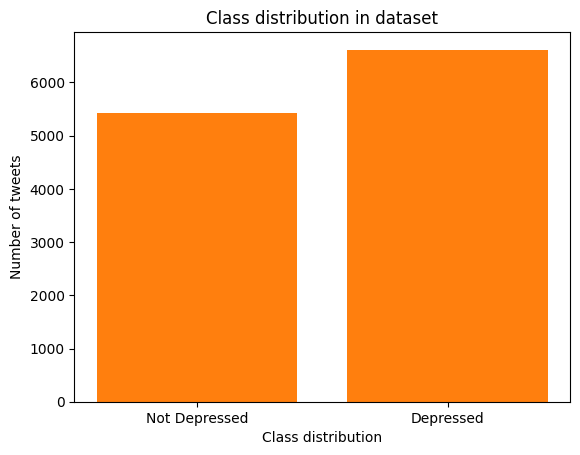

In [20]:
##Checking dataset balanced after balancing on tweets per user

unique_labels, counts = np.unique(filtered_tweets['label'], return_counts=True)
print(counts)
plt.bar(unique_labels, counts)
x_labels = ['Not Depressed', 'Depressed']
plt.bar(x_labels, counts)
plt.xlabel('Class distribution')
plt.ylabel('Number of tweets')
plt.title('Class distribution in dataset')
plt.show()

#print(len(filtered_tweets['label']==1))

# more depressed samples -->reduce depressed side --> within 10% of non depressed
#down sampling 

In [21]:
###Downsampling depressed tweets
#downsampling the amount of depressed tweets to be within 10% range of the amount of non-depressed tweets

#Separate depressed and non-depressed tweets
depressed_tweets = filtered_tweets[filtered_tweets['label'] == 1]
non_depressed_tweets = filtered_tweets[filtered_tweets['label'] == 0]

#count the number of depressed (label=1) and non-depressed (label=0) tweets
'''
depressed_count = filtered_tweets['label'].sum()
non_depressed_count = len(filtered_tweets) - depressed_count

'''
depressed_count = len(depressed_tweets)
non_depressed_count = len(non_depressed_tweets)
print(depressed_count)
# downsampled size for the depressed tweets
downsample_size = int(1.1 * non_depressed_count) 

if downsample_size > depressed_count:
    downsample_size = depressed_count
    #downsampling depressed tweets
    downsampled_depressed = depressed_tweets.sample(n=downsample_size, random_state=42)
else:
    downsampled_depressed = resample(depressed_tweets, replace=False, n_samples=downsample_size, random_state=42)


downsampled_filtered_tweets = pd.concat([downsampled_depressed, non_depressed_tweets])

#  randomize the order of tweets
downsampled_filtered_tweets = downsampled_filtered_tweets.sample(frac=1, random_state=42).reset_index(drop=True)

filtered_tweets = downsampled_filtered_tweets.copy()
unique_labels, counts = np.unique(filtered_tweets['label'], return_counts=True)
print(counts)



6614
[5423 5965]


Vectorisation
* TF-IDF
* Word2Vec

TFIDF Vectorisation 


In [22]:
#print(filtered_tweets['post_text'].head)
#analyzer='word',max_df=0.65, ngram_range=(1,2)
tfidfconverter = TfidfVectorizer(analyzer='word',max_df=0.85)
filtered_tweets['string_tweet'] = filtered_tweets['post_text'].apply(lambda tokens: ' '.join(tokens))
print(filtered_tweets['string_tweet'].head)
# fit and conveert the 'string_tweet' column

X = tfidfconverter.fit_transform(filtered_tweets['string_tweet'])
 
print(X)
tfidf_no_names_df = pd.DataFrame(X.toarray())
print(tfidf_no_names_df)
tfidf_no_names_df['label'] = filtered_tweets['label'].reset_index(drop=True)
#tfidf_no_names_df.to_csv('TF-IDF_vectorised_tweets_no_names.csv', index = False)
print(tfidf_no_names_df.head)
value = tfidf_no_names_df.iloc[0, 13541]
print(value)
#tfidf_df.to_csv('TF-IDF_vectorised_tweets.csv', index = False)

<bound method NDFrame.head of 0                                              rt nomyourself open letter arby http co miacqztk
1                                                                              go cold hot fast
2                                                              allthxngsozzie get damn straight
3               bbambz cognitive dissonance make sad show moral compass break still feel delude
4                                                                                              
                                                  ...                                          
11383    oh yes criminal record thing illegal do absolutely killin dancefloor haha kid kill man
11384                                                              rosemarytravale one see bear
11385                                     lil si really doin damn thing homemade pizza gt gt gt
11386                                          want able buy beer whenever feel like whether pm
11387     

In [23]:
tfidf_no_names_df.to_csv('TF-IDF_vectorised_tweets_no_names.csv', index = False)

In [24]:
tfidf_df = pd.DataFrame(X.toarray(), columns=tfidfconverter.get_feature_names_out())
tfidf_df['label'] = filtered_tweets['label'].reset_index(drop=True)

#tfidf_df.to_csv('TF-IDF_vectorised_tweets.csv', index = False)

#print(len(filtered_tweets['label']))
#print(len(filtered_tweets['post_text']))

Word2Vec vectorisation

In [27]:
##use tfidf aswell and run both through classfier and compare

# Train Word2Vec model
w2v = Word2Vec(sentences=filtered_tweets['post_text'], vector_size=200,min_count=2, sg=1)
#vector size to be 200
#window = defines max distance between current and predicted word within a sentence (small value better for tweets to capture local context well)
#min_count = minimum num of times a word must appear in dataset for it to be included in vocab
#sg = skip-gram --> training alogirhtm , skip gram better for smaller datasets,
w2v.save('word2vec_model.model') 
print("Vocabulary Length:", len(w2v.wv.key_to_index))
##using w2v model to get vector rep of each WORD




Vocabulary Length: 6327


In [28]:
#a function to get the vector representation for each TWEET
#represent each tweet as a vector by taking the average of the Word2Vec embeddings of the words in the tweet
#makes a vector representation of the tweet that shows how the words fit together and what they mean.

def tweet_vectorisation(w2v, tweet):
    #create vector list of size of w2v vectors (200)
    vector_sum = np.zeros((w2v.vector_size,), dtype="float32")
    word_count = 0
    #go through every word in tweet
    for word in tweet:
        #if the word exists in the w2v model word vectors 
        if word in w2v.wv:
            #add vector representation of word to vector sum 
            vector_sum =vector_sum +  w2v.wv[word]
            word_count = word_count+ 1
    if word_count != 0:
        #make average of the vector sum of the length of tweet
        #average taken to get a single vector representation of the tweet
        return vector_sum / word_count
    else:
        return vector_sum

filtered_tweets = pd.DataFrame(filtered_tweets)
filtered_tweets['vectorized_text'] = filtered_tweets['post_text'].apply(lambda x: tweet_vectorisation(w2v,x))


In [29]:
print(filtered_tweets['label'].head)

<bound method NDFrame.head of 0        1
1        1
2        1
3        1
4        0
        ..
11383    0
11384    1
11385    1
11386    1
11387    0
Name: label, Length: 11388, dtype: int64>


In [1]:
### word2vec experimentation
similar_words = w2v.wv.most_similar('depression')
print(similar_words)
print()
similar_words = w2v.wv.most_similar('anxiety')
print(similar_words)
print()
similar_words = w2v.wv.most_similar('disorder')
print(similar_words)


NameError: name 'w2v' is not defined

In [31]:
filtered_tweets.to_csv('Cleaned_and_balanced_labelled_dataset.csv', index = False)

ED and SA risk detection using Topic modelling (LDA)

Experimentation with hyperparameters of LDA - n_components=10, doc_topic_prior=0.01, topic_word_prior=0.01

In [50]:
dataset = tfidf_df
dataset = dataset.drop('label', axis=1)
lda = LatentDirichletAllocation(n_components=10, doc_topic_prior=0.01, topic_word_prior=0.01,max_iter=50,learning_method='batch',random_state=42)
lda.fit(dataset)

KeyboardInterrupt: 

In [ ]:
lda.get_feature_names_out
feature_names = tfidfconverter.get_feature_names_out()
top_word_num = 100

def show_topics(lda, feature_names, top_word_num):
    count=1
    for topic_idx, topic in enumerate(lda.components_):
        print("Topic", count ,topic_idx)
        print (" ".join([feature_names[i]
                        for i in topic.argsort()[:-top_word_num - 1:-1]]))
        count+=1

#print(feature_names)


Experimentation with hyperparameters of LDA - n_components=10, doc_topic_prior=0.5, topic_word_prior=0.5

In [ ]:
###LDA topic modelling to identify ED risks and SA risk based on identified topics 

#which hyperparamters are best- test out doc_topic_prior (0.1, 0.5,1), topic_word_prior (0.1, 0.5,1), n_components= 7,10,15
lda = LatentDirichletAllocation(n_components=10, doc_topic_prior=0.5, topic_word_prior=0.5,max_iter=50,learning_method='batch',random_state=42)


#drop label so its just document term matrix + fit lda model to the matrix 
lda.fit(dataset)
#lda.show_topics()
feature_names = tfidfconverter.get_feature_names_out()
top_word_num = 100
show_topics(lda, feature_names, top_word_num)

##best model for alpha and beta, topic 6 seemed to fit depression in general so wanted to explore trying more topics to see if we could break it down further 

KeyboardInterrupt: 

Experimentation with hyperparameters of LDA - n_components=10, doc_topic_prior=1, topic_word_prior=1

In [ ]:
lda = LatentDirichletAllocation(n_components=10, doc_topic_prior=1, topic_word_prior=1,max_iter=50,learning_method='batch',random_state=42)
lda.fit(dataset)


LatentDirichletAllocation(doc_topic_prior=1, max_iter=50, random_state=42,
                          topic_word_prior=1)

In [ ]:
lda.get_feature_names_out
feature_names = tfidfconverter.get_feature_names_out()
top_word_num = 100

def show_topics(lda, feature_names, top_word_num):
    count=1
    for topic_idx, topic in enumerate(lda.components_):
        print("Topic", count ,topic_idx)
        print (" ".join([feature_names[i]
                        for i in topic.argsort()[:-top_word_num - 1:-1]]))
        count+=1

#print(feature_names)
show_topics(lda, feature_names, top_word_num)
ED = np.where(feature_names=="binge")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'binge' is closest to topic " ,closest_topic)

Topic 1 0
http co rsyhva1hpd get go liithurmanator lovato ond know good makcik timcowlishaw wangi pentatonix fuck worx nedsudbeck day thingy sawyerhartman sedxiigb26 depression feel loofranchot tak lies yeahhh usem amp muc rig thine nevsmia wore stiletto neve reallly yomwdyaidy mammy todate friend come follow tali even television happy truthsweb somehow waxpancake ursula always thankfully ogyofybfds truman hey cameronhoodkin lesson lokeren welker thai shirtless back could waistline tweeps god girl hate stooooooop give 5sos starringoakley wat sleeker help realchriswebber vi9qxsgg89 great twitch everyone lashton game first find https ever bad keep guy change ask hope somerset call treatme lydia gt shove mealtime
Topic 2 1
co http rsyhva1hpd liithurmanator get go ond lovato good makcik know thingy pentatonix worx fuck day timcowlishaw loofranchot nedsudbeck wangi sedxiigb26 sawyerhartman depression feel yeahhh usem lies tak amp rig nevsmia muc neve wore yomwdyaidy thine stiletto reallly m

In [ ]:
###LDA topic modelling to identify ED risks and SA risk based on identified topics 
### **best one 

#which hyperparamters are best??
#n_components = number of topics (5, 7, 10)
# doc_topic_prior = controls document-topic distribution (0.001, 0.5, 1)
lda = LatentDirichletAllocation(n_components=15, doc_topic_prior=0.5, topic_word_prior=0.5,max_iter=50,learning_method='batch',random_state=42)
dataset = tfidf_df
dataset = dataset.drop('label', axis=1)

#drop label so its just document term matrix + fit lda model to the matrix 
lda.fit(dataset)
#lda.show_topics()

LatentDirichletAllocation(doc_topic_prior=0.5, max_iter=50, n_components=15,
                          random_state=42, topic_word_prior=0.5)

In [ ]:
lda.get_feature_names_out
feature_names = tfidfconverter.get_feature_names_out()
top_word_num = 100

def show_topics(lda, feature_names, top_word_num):
    count=1
    for topic_idx, topic in enumerate(lda.components_):
        print("Topic" ,topic_idx)
        print (" ".join([feature_names[i]
                        for i in topic.argsort()[:-top_word_num - 1:-1]]))
        count+=1

#print(feature_names)
        
##topics key ED behaivours are associated with 
        
##ED language 
show_topics(lda, feature_names, top_word_num)
ED = np.where(feature_names=="anorexia")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'anorexia' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="bulimia")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'bulimia' is closest to topic " ,closest_topic)


##extreme dietting

ED = np.where(feature_names=="diet")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'diet' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="starve")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'starve' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="binge")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'binge' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="purge")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'purge' is closest to topic " ,closest_topic)
##mood and personality disorders 

ED = np.where(feature_names=="bipolar")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'bipolar' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="borderline")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'borderline' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="disorder")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'disorder' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="ocd")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'ocd' is closest to topic " ,closest_topic)







Topic 0
hananyxnyx thanksstevie moveon netanyahu goat izatihashim trendinaliapi bee budget elvish dope literally breathe deadpool idyu anashssn immersion coltemonlkha ntrpvbmivw mahctekydnam awh flawlesspayno ceudeaaxf souljaboy pasta arnintsha shaane hp heavily sylvester thatwiggadev theieansquad opine sleek ahahahhaah pickup though espnnfl diinvrhx yas motherjones maximmag suggest zkympgf yaboylilb ridddzuan itisitiariff injpggxjmt theanimebible doco shehatesjacoby albus lucky fegt ewanroslan hulu humzasohail passio tonyv azfar ooooo commitment messian construction esok success mingjuechen appreciate frvnkvx temperature mys gander allfxbrokers patron iriswestaiin co siti avenger magnitude opuferc spider juksiwzp tailgate accordance cuma cancel button johor peta tayo horizontally invertef engrave speedrun lewisville clearwater worthingutdfc nots ring invent
Topic 1
trum co position liddis realdonaldrumpf puteih joe veganoutreach vega account wimfays joenbc poh animal presidency whispe

Topic association of ED behaviours

In [ ]:
##body dissatisfaction 

ED = np.where(feature_names=="ugly")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'ugly' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="fat")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'fat' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="obese")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'obese' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="thin")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'thin' is closest to topic " ,closest_topic)

#show_topics(lda, feature_names, top_word_num)
ED = np.where(feature_names=="anorexia")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'anorexia' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="bulimia")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'bulimia' is closest to topic " ,closest_topic)


##extreme dietting

ED = np.where(feature_names=="diet")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'diet' is closest to topic " ,closest_topic)

#ED = np.where(feature_names=="dietting")
#ED_topic = lda.components_[:, ED]
#closest_topic = ED_topic.argmax()
#print("The word 'dietting' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="skinny")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'skinny' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="waistline")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'waistline' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="starve")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'starve' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="binge")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'binge' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="purge")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'purge' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="vomit")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'vomit' is closest to topic " ,closest_topic)

#ED = np.where(feature_names=="starving")
#ED_topic = lda.components_[:, ED]
#closest_topic = ED_topic.argmax()
#print("The word 'starving' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="hungry")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'hungry' is closest to topic " ,closest_topic)
##mood and personality disorders 

ED = np.where(feature_names=="bipolar")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'bipolar' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="borderline")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'borderline' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="disorder")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'disorder' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="ocd")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'ocd' is closest to topic " ,closest_topic)

#ED = np.where(feature_names=="obsessive")
#ED_topic = lda.components_[:, ED]
#closest_topic = ED_topic.argmax()
#print("The word 'obsessive' is closest to topic " ,closest_topic)

The word 'ugly' is closest to topic  1
The word 'fat' is closest to topic  14
The word 'obese' is closest to topic  9
The word 'thin' is closest to topic  14
The word 'anorexia' is closest to topic  14
The word 'bulimia' is closest to topic  14
The word 'diet' is closest to topic  14
The word 'skinny' is closest to topic  1
The word 'waistline' is closest to topic  6
The word 'starve' is closest to topic  6
The word 'binge' is closest to topic  14
The word 'purge' is closest to topic  4
The word 'vomit' is closest to topic  14
The word 'hungry' is closest to topic  14
The word 'bipolar' is closest to topic  14
The word 'borderline' is closest to topic  14
The word 'disorder' is closest to topic  14
The word 'ocd' is closest to topic  14


Topic association of SA behaviours

In [ ]:
##SA language 
#show_topics(lda, feature_names, top_word_num)
ED = np.where(feature_names=="drug")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'drug' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="alcohol")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'alcohol' is closest to topic " ,closest_topic)


ED = np.where(feature_names=="drunk")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'drunk' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="coke")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'coke' is closest to topic " ,closest_topic)


ED = np.where(feature_names=="addiction")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'addiction' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="weed")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'weed' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="overdose")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'overdose' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="fail")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'fail' is closest to topic " ,closest_topic)

##sleep issues
ED = np.where(feature_names=="sleep")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'sleep' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="insomnia")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'insomnia' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="substance")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'substance' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="abuse")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'abuse' is closest to topic " ,closest_topic)

#suicidal ideation 
ED = np.where(feature_names=="suicide")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'suicide' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="kill")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'kill' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="suicidal")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'suicidal' is closest to topic " ,closest_topic)

ED = np.where(feature_names=="selfharm")
ED_topic = lda.components_[:, ED]
closest_topic = ED_topic.argmax()
print("The word 'selfharm' is closest to topic " ,closest_topic)
##mood disroders also correlate highly with substance abuse

The word 'drug' is closest to topic  14
The word 'alcohol' is closest to topic  14
The word 'drunk' is closest to topic  14
The word 'coke' is closest to topic  14
The word 'addiction' is closest to topic  14
The word 'weed' is closest to topic  6
The word 'overdose' is closest to topic  14
The word 'fail' is closest to topic  14
The word 'sleep' is closest to topic  14
The word 'insomnia' is closest to topic  14
The word 'substance' is closest to topic  14
The word 'abuse' is closest to topic  14
The word 'suicide' is closest to topic  5
The word 'kill' is closest to topic  14
The word 'suicidal' is closest to topic  14
The word 'selfharm' is closest to topic  14


In [ ]:
topic_matrix = lda.fit_transform(dataset)
#dominant_topic = topic_matrix.argmax(axis=1)
threshold = 0.3

#tfidf_df['Dominant_Topic'] = dominant_topic
print(tfidf_df.head())

   aaaaaaazfar  aaaaaiiigh  aaaaand  aaffu  aag  aaibnmpfr  aaka  \
0          0.0         0.0      0.0    0.0  0.0        0.0   0.0   
1          0.0         0.0      0.0    0.0  0.0        0.0   0.0   
2          0.0         0.0      0.0    0.0  0.0        0.0   0.0   
3          0.0         0.0      0.0    0.0  0.0        0.0   0.0   
4          0.0         0.0      0.0    0.0  0.0        0.0   0.0   

   aalexandriabish  aaotzf  aaron  ...  zyyhaywr  zzehmbaka  zzezqbx  \
0              0.0     0.0    0.0  ...       0.0        0.0      0.0   
1              0.0     0.0    0.0  ...       0.0        0.0      0.0   
2              0.0     0.0    0.0  ...       0.0        0.0      0.0   
3              0.0     0.0    0.0  ...       0.0        0.0      0.0   
4              0.0     0.0    0.0  ...       0.0        0.0      0.0   

   zzfhxrhork  zzjhv  zzmqbjcjk  zzoaisg  zzqywzdlv  zzsjzkpjt  zzwjuoou  
0         0.0    0.0        0.0      0.0        0.0        0.0       0.0  
1       

LAbelling SA and ED risk based of association with topics

In [ ]:

ED_labels =[]
topic_matrix_df = pd.DataFrame(topic_matrix)
print(topic_matrix_df)
def label_ED_risk(list):
    #print(list[13], list[6])
    if list[14]>=0.1 and list[6]>=0.08 and list[1]>=0.05:
        return 1
        
    else:
        #print(list[13], list[6])
        return 0
    
tfidf_df['ED_risk2'] = topic_matrix_df.apply(label_ED_risk,axis=1)
#print(tfidf_df.head())

#tfidf_df.to_csv('TF-IDF_vectorised_tweets.csv', index = False)

tfidf_df['ED_risk2'].fillna(0, inplace=True)

# Replace 1.0 values with 1 in 'Column_Name'
tfidf_df['ED_risk2'].replace(1.0, 1, inplace=True)
tfidf_df['ED_risk2'] = tfidf_df['ED_risk2'].astype(int)

count_of_ones = (tfidf_df['ED_risk2'] == 1.0).sum()

print("Number of 1s in 'ed risk':", count_of_ones)
print(tfidf_df['ED_risk2'].head)


             0         1         2         3         4         5         6   \
0      0.054686  0.056038  0.076742  0.055912  0.056141  0.055678  0.056030   
1      0.053300  0.053382  0.252832  0.053391  0.053389  0.053361  0.053378   
2      0.052294  0.052474  0.228207  0.052432  0.052458  0.052557  0.052435   
3      0.059283  0.053424  0.235535  0.053309  0.053565  0.052928  0.053084   
4      0.119397  0.058937  0.117173  0.058822  0.059007  0.058694  0.058772   
...         ...       ...       ...       ...       ...       ...       ...   
11383  0.066667  0.066667  0.066667  0.066667  0.066667  0.066667  0.066667   
11384  0.057596  0.058678  0.167232  0.058774  0.058771  0.058303  0.058450   
11385  0.061988  0.052385  0.250762  0.052355  0.052390  0.052281  0.052406   
11386  0.049026  0.049201  0.311590  0.049173  0.049213  0.049137  0.049155   
11387  0.054599  0.055451  0.173411  0.076664  0.055513  0.055162  0.055640   

             7         8         9         10      

In [ ]:
print(topic_matrix_df)
def label_SA_risk(list):
    #print(list[13], list[6])
    if list[2]>=0.1 and list[14]>=0.1 and list[12]>=0.01 and list[7]>=0.01:
        return 1
        
    else:
        #print(list[13], list[6])
        return 0
    
tfidf_df['SA_risk2'] = topic_matrix_df.apply(label_SA_risk,axis=1)
#print(tfidf_df.head())

#tfidf_df.to_csv('TF-IDF_vectorised_tweets.csv', index = False)

tfidf_df['SA_risk2'].fillna(0, inplace=True)

# Replace 1.0 values with 1 in 'Column_Name'
tfidf_df['SA_risk2'].replace(1.0, 1, inplace=True)
tfidf_df['SA_risk2'] = tfidf_df['ED_risk2'].astype(int)

count_of_ones = (tfidf_df['SA_risk2'] == 1).sum()

print("Number of 1s in 'sa risk':", count_of_ones)
print(tfidf_df['SA_risk2'].head)

             0         1         2         3         4         5         6   \
0      0.054686  0.056038  0.076742  0.055912  0.056141  0.055678  0.056030   
1      0.053300  0.053382  0.252832  0.053391  0.053389  0.053361  0.053378   
2      0.052294  0.052474  0.228207  0.052432  0.052458  0.052557  0.052435   
3      0.059283  0.053424  0.235535  0.053309  0.053565  0.052928  0.053084   
4      0.119397  0.058937  0.117173  0.058822  0.059007  0.058694  0.058772   
...         ...       ...       ...       ...       ...       ...       ...   
11383  0.066667  0.066667  0.066667  0.066667  0.066667  0.066667  0.066667   
11384  0.057596  0.058678  0.167232  0.058774  0.058771  0.058303  0.058450   
11385  0.061988  0.052385  0.250762  0.052355  0.052390  0.052281  0.052406   
11386  0.049026  0.049201  0.311590  0.049173  0.049213  0.049137  0.049155   
11387  0.054599  0.055451  0.173411  0.076664  0.055513  0.055162  0.055640   

             7         8         9         10      

In [ ]:
#tfidf_df.to_csv('TF-IDF_vectorised_tweets.csv', index = False)

In [ ]:
tfidf_df['label'] = filtered_tweets['label'].reset_index(drop=True)
print(tfidf_df.head)
tfidf_df.to_csv('TF-IDF_vectorised_tweets.csv', index = False)

<bound method NDFrame.head of        aaa  aaaaand  aaahhg  aaffu  aag  aagyubnll  aaibnmpfr  aaka  \
0      0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
1      0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
2      0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
3      0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
4      0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
...    ...      ...     ...    ...  ...        ...        ...   ...   
11383  0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
11384  0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
11385  0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
11386  0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   
11387  0.0      0.0     0.0    0.0  0.0        0.0        0.0   0.0   

       aalexandriabish  aaomzuva  ...  zzapfmtl  zzehmbaka  zzezqbx  zzjhv  \
0                  0.0       0.0  ...  

In [ ]:
ed_count = (tfidf_df['ED_risk2'] == 1.0).sum()

print("Number of True values:", ed_count)
value_distribution = tfidf_df['Dominant_Topic'].value_counts()

# Print the distribution
print(value_distribution)

Number of True values: 15
Dominant_Topic
2     5753
14    5632
7        2
0        1
Name: count, dtype: int64


Word clouds for SA and ED topics

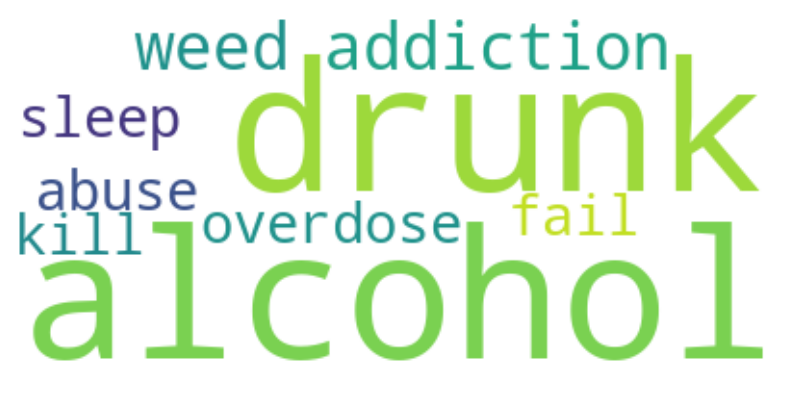

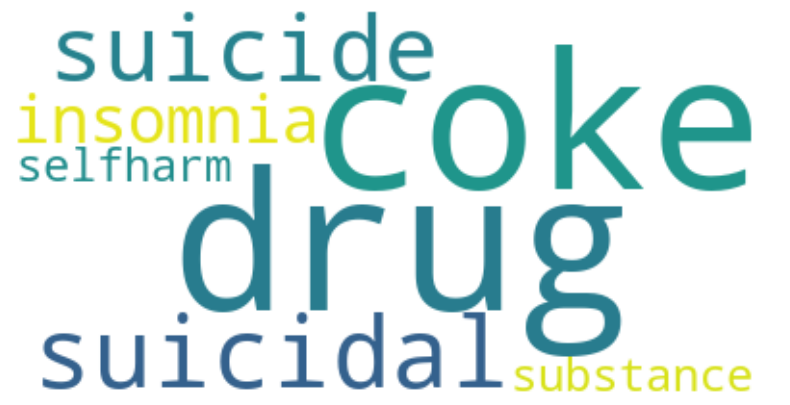

In [ ]:



SA_words = 'alcohol, drunk, addiction, weed, overdose fail, sleep, abuse, kill'
wordcloud = WordCloud(width=400, height=200, background_color="white").generate(SA_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axis
plt.show()

SA_words = 'drug, coke, suicidal, suicide, insomnia substance, selfharm'
wordcloud = WordCloud(width=400, height=200, background_color="white").generate(SA_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axis
plt.show()



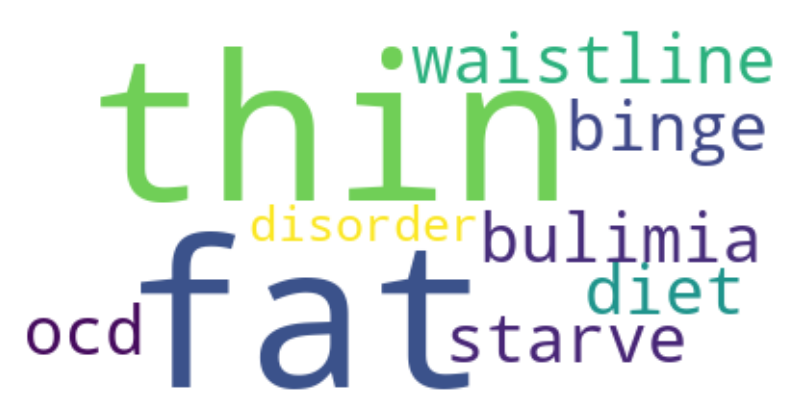

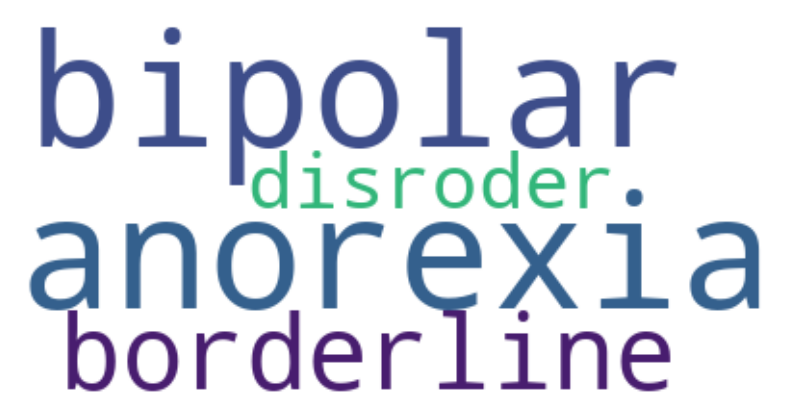

In [ ]:
ED_words = 'fat, thin, waistline, bulimia, diet, starve,binge, ocd, disorder'
ED_words2= 'anorexia, bipolar, borderline, disroder'
#topics = 4
wordcloud = WordCloud(width=400, height=200, background_color="white").generate(ED_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axis
plt.show()

wordcloud = WordCloud(width=400, height=200, background_color="white").generate(ED_words2)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axis
plt.show()

Experimentation 


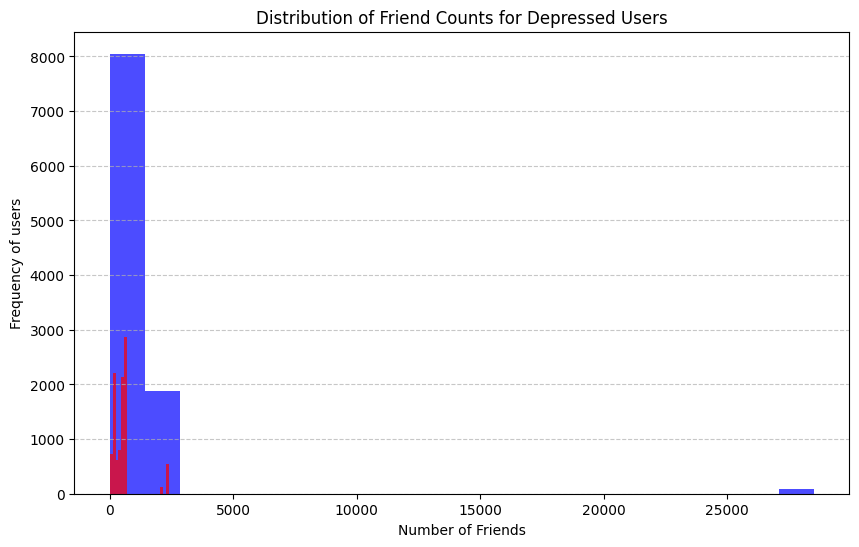

In [ ]:
##
'''
###depressed/ non depressed users and number of friends
import matplotlib.pyplot as plt

# Assuming 'user_id' and 'friends' are columns in your DataFrame
depressed_users = tweets[tweets['label'] == 1]
non_depressed_users = tweets[tweets['label'] == 0]

# Plot a histogram of friend counts for depressed users
plt.figure(figsize=(10, 6))
plt.hist(depressed_users['friends'], bins=20, color='blue', alpha=0.7)
plt.hist(non_depressed_users['friends'], bins=20, color='red', alpha=0.7)
plt.title('Distribution of Friend Counts for Depressed Users')
plt.xlabel('Number of Friends')
plt.ylabel('Frequency of users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
'''

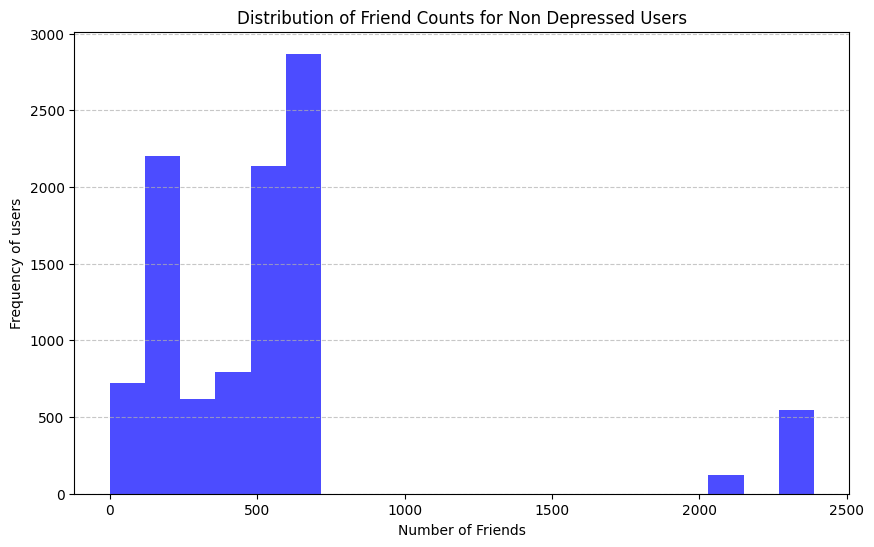

In [ ]:
###depressed/ non depressed users and number of friends
import matplotlib.pyplot as plt

# Assuming 'user_id' and 'friends' are columns in your DataFrame
depressed_users = tweets[tweets['label'] == 0]

# Plot a histogram of friend counts for depressed users
plt.figure(figsize=(10, 6))
plt.hist(depressed_users['friends'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Friend Counts for Non Depressed Users')
plt.xlabel('Number of Friends')
plt.ylabel('Frequency of users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
##top 20 used hashtags for depressed and non depressed uers 
##unnecessary for this part --> better for looking at second dataset 
depressed_tweets = filtered_tweets[filtered_tweets['label'] == 1]['hashtags']
non_depressed_tweets = filtered_tweets[filtered_tweets['label'] == 0]['hashtags']

# makes sure all entries are strings and concatenate them
depressed_hashtags = ','.join(depressed_tweets.dropna().apply(lambda x: ', '.join(x) if isinstance(x, list) else x))
non_depressed_hashtags = ','.join(non_depressed_tweets.dropna().apply(lambda x: ', '.join(x) if isinstance(x, list) else x))


def tokenize_and_count(hashtags_str):
    return [tag.strip() for tag in hashtags_str.split(',')]

depressed_hashtag_counts = Counter(tokenize_and_count(depressed_hashtags))
non_depressed_hashtag_counts = Counter(tokenize_and_count(non_depressed_hashtags))

# Top hashtags for depressed and non depressed users to do aanlyses on 
top_depressed_hashtags = depressed_hashtag_counts.most_common(20)
top_non_depressed_hashtags = non_depressed_hashtag_counts.most_common(20)

print('Top 20 depressed hashtags: ', top_depressed_hashtags)
print()
print('Top 20 non depressed hashtags: ', top_non_depressed_hashtags)

Top 20 depressed hashtags:  [('', 4928), ('BBMAs', 44), ('autism', 39), ('mnwild', 29), ('addiction', 24), ('HeyEverybodyMusicVideo', 17), ('depression', 16), ('anxiety', 14), ('BellLetsTalk', 13), ('mentalhealth', 13), ('vegan', 13), ('parenting', 12), ('children', 10), ('Massage', 10), ('relationships', 9), ('5sos', 9), ('5sosfam', 9), ('mentalillness', 9), ('Leo', 8), ('XFactor', 8)]

Top 20 non depressed hashtags:  [('', 5035), ('BestMusicVideo', 74), ('iHeartAwards', 72), ('Pillowtalk', 50), ('YONGKISSReturnOnPbb', 27), ('MostRequestedLive', 25), ('IDontWannaLiveForever', 21), ('NowZayn', 14), ('now2016', 13), ('PillowTalk', 13), ('Lions', 12), ('NBAVOTE', 10), ('PILLOWTALK', 9), ('LyingDonaldTrump', 9), ('NFL', 8), ('Shadowhunters', 7), ('Riverdale', 7), ('Patriots', 7), ('MNF', 6), ('ck', 6)]
